<a href="https://colab.research.google.com/github/cayang17/ds3001_GroupR/blob/main/final_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Obesity Prediction: Machine Learning Models
## DS 3001

This notebook implements multiple classification models:
- k-Nearest Neighbors (kNN) Classification
- Decision Tree Classification
- Logistic Regression Classification
- Principal Component Analysis (PCA)
- k-Means Clustering

**Authors**: Caleb Kim, Daniel Song, Christina Yang  

# Data Cleaning and Merging

Data cleaning and merging of multiple datasets:
- BRFSS 2017 (individual health behaviors)
- USDA Food Environment Atlas (stores, restaurants, access)
- Census 2017 (socioeconomic data)

All datasets will be aggregated/merged at the state level.

Make sure LLCP2017.XPT, access.csv, census2017.csv, restaurants.csv, and stores.csv are in the content folder on Google Colab.

# Convert XPT file to CSV

In [1]:
import pandas as pd

# Need to convert original XPT file to CSV

# Load the XPT file
df = pd.read_sas("/content/LLCP2017.XPT ")

# Save as CSV
df.to_csv("/content/BRFSS_2017.csv", index=False)

print("Conversion complete and file saved as BRFSS_2017.csv")
df.head()

/tmp/ipython-input-1629037146.py:6: UserWarning: xport file may be corrupted.
  df = pd.read_sas("/content/LLCP2017.XPT ")


Conversion complete and file saved as BRFSS_2017.csv


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_PA300R2,_PA30021,_PASTRNG,_PAREC1,_PASTAE1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01302017',b'01',b'30',b'2017',1100.0,b'2017000001',2.017000e+09,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,b'01122017',b'01',b'12',b'2017',1100.0,b'2017000002',2.017000e+09,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,b'01102017',b'01',b'10',b'2017',1100.0,b'2017000003',2.017000e+09,1.0,...,3.0,2.0,2.0,4.0,2.0,1.0,1.0,1.0,1.0,2.0
3,1.0,1.0,b'02082017',b'02',b'08',b'2017',1200.0,b'2017000004',2.017000e+09,1.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,NaN
4,1.0,1.0,b'01302017',b'01',b'30',b'2017',1100.0,b'2017000005',2.017000e+09,1.0,...,3.0,2.0,2.0,4.0,2.0,1.0,2.0,2.0,2.0,2.0


In [2]:
from google.colab import files
files.download("/content/BRFSS_2017.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Keep needed columns

In [3]:
import pandas as pd

# Need to remove the columns that will not be used

# LOAD BRFSS
df = pd.read_csv("/content/BRFSS_2017.csv", low_memory=False)

print("Original shape:", df.shape)


# Select the columns used
keep_cols = [
    '_BMI5',
    '_AGE80',
    'SEX',
    '_IMPRACE',
    'INCOME2',
    'EXERANY2',
    'PA1MIN_',
    'SMOKE100',
    'SMOKDAY2',
    'ALCDAY5',
    'DRNK3GE5',
    'FRUIT2',
    'VEGETAB2',
    '_STATE',
    '_CNTYFIP'
]

# Filter only the columns that exist (some variables vary by year)
existing_cols = [c for c in keep_cols if c in df.columns]

df_small = df[existing_cols].copy()

print("Columns kept:", existing_cols)
print("Shape after keeping only needed columns:", df_small.shape)


# Clean data (drop rows missing key valuess
# Drop rows with missing BMI or county FIPS
critical_vars = ['_BMI5', '_STATE']
critical_vars = [c for c in critical_vars if c in df_small.columns]

df_small = df_small.dropna(subset=critical_vars)

# onvert special BRFSS missing codes (777=don’t know, 999=refused)
df_small.replace({777: None, 999: None, 888: None}, inplace=True)

print("Shape after cleaning:", df_small.shape)

# Create binary obesity outcome
# BRFSS stores BMI as BMI * 100. So 3000 = BMI of 30.
if '_BMI5' in df_small.columns:
    df_small['OBESE'] = (df_small['_BMI5'] >= 3000).astype(int)

# 5. Save cleaned dataset
output_path = "/content/CDCBRFSS_2017.csv"
df_small.to_csv(output_path, index=False)

print("Saved cleaned dataset to:", output_path)
df_small.head()


Original shape: (126705, 358)
Columns kept: ['_BMI5', '_AGE80', 'SEX', '_IMPRACE', 'INCOME2', 'EXERANY2', 'PA1MIN_', 'SMOKE100', 'SMOKDAY2', 'ALCDAY5', 'DRNK3GE5', 'FRUIT2', 'VEGETAB2', '_STATE']
Shape after keeping only needed columns: (126705, 14)
Shape after cleaning: (116139, 14)
Saved cleaned dataset to: /content/CDCBRFSS_2017.csv


,_BMI5,_AGE80,SEX,_IMPRACE,INCOME2,EXERANY2,PA1MIN_,SMOKE100,SMOKDAY2,ALCDAY5,DRNK3GE5,FRUIT2,VEGETAB2,_STATE,OBESE
0,2696.0,74.0,2.0,1.0,6.0,1.0,360.0,2.0,NaN,None,NaN,102.0,101.0,1.0,0
1,2943.0,67.0,1.0,1.0,8.0,1.0,420.0,2.0,NaN,None,NaN,103.0,101.0,1.0,0
2,2504.0,70.0,1.0,1.0,99.0,2.0,NaN,2.0,NaN,101.0,88.0,202.0,201.0,1.0,0
3,2663.0,73.0,2.0,1.0,1.0,NaN,NaN,2.0,NaN,None,NaN,301.0,NaN,1.0,0
4,2330.0,69.0,2.0,1.0,2.0,2.0,NaN,1.0,3.0,None,NaN,101.0,303.0,1.0,0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [5]:
# Load all datasets
brfss = pd.read_csv('/content/CDCBRFSS_2017.csv')
stores = pd.read_csv('/content/stores.csv')
restaurants = pd.read_csv('/content/restaurants.csv')
access = pd.read_csv('/content/access.csv')
census = pd.read_csv('/content/census2017.csv')

print("Dataset Shapes:")
print(f"BRFSS: {brfss.shape}")
print(f"Stores: {stores.shape}")
print(f"Restaurants: {restaurants.shape}")
print(f"Access: {access.shape}")
print(f"Census: {census.shape}")

Dataset Shapes:
BRFSS: (116139, 15)
Stores: (3143, 39)
Restaurants: (3143, 19)
Access: (3143, 44)
Census: (68, 625)


## 2. Clean BRFSS Data (Individual Health Behaviors)

The BRFSS dataset contains individual-level survey responses. We need to:
1. Convert BMI from coded values (BMI * 100) to actual BMI
2. Handle missing values and invalid responses
3. Recode categorical variables
4. Create state mapping

In [6]:
# Create state FIPS to state name mapping
state_fips_mapping = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY', 72: 'PR'
}

# Map state codes to abbreviations
brfss['State'] = brfss['_STATE'].map(state_fips_mapping)

print(f"\nOriginal BRFSS shape: {brfss.shape}")
print(f"Number of states: {brfss['State'].nunique()}")
print(f"\nStates in dataset: {sorted(brfss['State'].unique())}")


Original BRFSS shape: (116139, 16)
Number of states: 15

States in dataset: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN']


In [7]:
# Convert BMI from coded values (BMI * 100) to actual BMI
brfss['BMI'] = brfss['_BMI5'] / 100

# Filter out unrealistic BMI values (keep BMI between 15 and 60)
print(f"\nBMI distribution before filtering:")
print(brfss['BMI'].describe())

brfss_clean = brfss[(brfss['BMI'] >= 15) & (brfss['BMI'] <= 60)].copy()

print(f"\nRows removed due to unrealistic BMI: {len(brfss) - len(brfss_clean)}")
print(f"\nBMI distribution after filtering:")
print(brfss_clean['BMI'].describe())


BMI distribution before filtering:
count    116139.000000
mean         27.903268
std           6.239891
min          12.110000
25%          23.670000
50%          26.730000
75%          30.900000
max          97.850000
Name: BMI, dtype: float64

Rows removed due to unrealistic BMI: 286

BMI distribution after filtering:
count    115853.000000
mean         27.864203
std           6.050232
min          15.000000
25%          23.670000
50%          26.720000
75%          30.900000
max          59.970000
Name: BMI, dtype: float64


In [8]:
# Verify obesity status matches BMI
brfss_clean['OBESE_CALCULATED'] = (brfss_clean['BMI'] >= 30).astype(int)

print(f"\nObesity status comparison:")
print(f"Original OBESE variable: {brfss_clean['OBESE'].sum()} obese individuals")
print(f"Calculated from BMI: {brfss_clean['OBESE_CALCULATED'].sum()} obese individuals")
print(f"Match rate: {(brfss_clean['OBESE'] == brfss_clean['OBESE_CALCULATED']).mean():.2%}")

# Use the calculated obesity status
brfss_clean['OBESE'] = brfss_clean['OBESE_CALCULATED']


Obesity status comparison:
Original OBESE variable: 34119 obese individuals
Calculated from BMI: 34119 obese individuals
Match rate: 100.00%


In [9]:
# Recode SEX (1=Male, 2=Female) to binary (0=Female, 1=Male)
brfss_clean['MALE'] = (brfss_clean['SEX'] == 1).astype(int)

# Age is already in years (_AGE80)
brfss_clean['AGE'] = brfss_clean['_AGE80']

# Race/Ethnicity (_IMPRACE: 1=White, 2=Black, 3=Asian, 4=Native American, 5=Hispanic, 6=Other)
# Create binary indicators for major groups
brfss_clean['RACE_WHITE'] = (brfss_clean['_IMPRACE'] == 1).astype(int)
brfss_clean['RACE_BLACK'] = (brfss_clean['_IMPRACE'] == 2).astype(int)
brfss_clean['RACE_HISPANIC'] = (brfss_clean['_IMPRACE'] == 5).astype(int)

print("\nDemographic variables created:")
print(f"Male: {brfss_clean['MALE'].mean():.2%}")
print(f"Average age: {brfss_clean['AGE'].mean():.1f} years")
print(f"White: {brfss_clean['RACE_WHITE'].mean():.2%}")
print(f"Black: {brfss_clean['RACE_BLACK'].mean():.2%}")
print(f"Hispanic: {brfss_clean['RACE_HISPANIC'].mean():.2%}")


Demographic variables created:
Male: 45.79%
Average age: 55.4 years
White: 70.79%
Black: 9.91%
Hispanic: 9.67%


In [10]:
# Handle Income (INCOME2: 1=<$10k, 2=$10-15k, 3=$15-20k, 4=$20-25k, 5=$25-35k,
#                        6=$35-50k, 7=$50-75k, 8=$75k+, 77/99=DK/Refused)
# Replace DK/Refused with NaN
brfss_clean['INCOME'] = brfss_clean['INCOME2'].replace([77, 99], np.nan)

print(f"\nIncome variable:")
print(f"Missing income values: {brfss_clean['INCOME'].isna().sum()} ({brfss_clean['INCOME'].isna().mean():.2%})")
print(f"\nIncome distribution:")
print(brfss_clean['INCOME'].value_counts(dropna=False).sort_index())


Income variable:
Missing income values: 16165 (13.95%)

Income distribution:
INCOME
1.0     4889
2.0     5144
3.0     7509
4.0     9267
5.0    10606
6.0    13716
7.0    15254
8.0    33303
NaN    16165
Name: count, dtype: int64


In [11]:
# Exercise variables
# EXERANY2: 1=Yes, 2=No, 7/9=DK/Refused
brfss_clean['EXERCISE'] = brfss_clean['EXERANY2'].replace([7, 9], np.nan)
brfss_clean['EXERCISE'] = (brfss_clean['EXERCISE'] == 1).astype(float)

# PA1MIN_ is minutes of physical activity per week (already continuous)
brfss_clean['PHYSICAL_ACTIVITY_MIN'] = brfss_clean['PA1MIN_']

print(f"\nExercise variables:")
print(f"Any exercise in past month: {brfss_clean['EXERCISE'].mean():.2%}")
print(f"Average PA minutes per week: {brfss_clean['PHYSICAL_ACTIVITY_MIN'].mean():.1f}")


Exercise variables:
Any exercise in past month: 68.66%
Average PA minutes per week: 516.6


In [12]:
# Smoking variables
# SMOKE100: 1=Yes (smoked 100+ cigarettes), 2=No, 7/9=DK/Refused
brfss_clean['EVER_SMOKER'] = brfss_clean['SMOKE100'].replace([7, 9], np.nan)
brfss_clean['EVER_SMOKER'] = (brfss_clean['EVER_SMOKER'] == 1).astype(float)

# SMOKDAY2: 1=Daily, 2=Some days, 3=Not at all, 7/9=DK/Refused (only for those who smoked 100+)
brfss_clean['CURRENT_SMOKER'] = brfss_clean['SMOKDAY2'].replace([7, 9], np.nan)
brfss_clean['CURRENT_SMOKER'] = (brfss_clean['CURRENT_SMOKER'].isin([1, 2])).astype(float)

print(f"\nSmoking variables:")
print(f"Ever smoker: {brfss_clean['EVER_SMOKER'].mean():.2%}")
print(f"Current smoker: {brfss_clean['CURRENT_SMOKER'].mean():.2%}")


Smoking variables:
Ever smoker: 42.19%
Current smoker: 14.38%


In [13]:
# Alcohol variables
# ALCDAY5: Days had alcoholic beverages in past 30 days (coded: 1XX=days, 2XX=weeks)
# DRNK3GE5: Binge drinking occasions in past 30 days

# Convert ALCDAY5 to days per month
def convert_alcday(x):
    if pd.isna(x) or x in [777, 888, 999]:
        return np.nan
    if x == 0:
        return 0
    if 100 < x < 200:  # Days per month
        return x - 100
    if 200 < x < 300:  # Weeks per month (convert to days)
        return (x - 200) * 7 / 30 * 30
    return np.nan

brfss_clean['ALCOHOL_DAYS'] = brfss_clean['ALCDAY5'].apply(convert_alcday)
brfss_clean['BINGE_DRINKING'] = brfss_clean['DRNK3GE5'].replace([77, 88, 99], np.nan)

print(f"\nAlcohol variables:")
print(f"Average drinking days per month: {brfss_clean['ALCOHOL_DAYS'].mean():.1f}")
print(f"Average binge drinking occasions: {brfss_clean['BINGE_DRINKING'].mean():.1f}")


Alcohol variables:
Average drinking days per month: 44.5
Average binge drinking occasions: 4.5


In [14]:
# Dietary variables
# FRUIT2: Times consumed fruit per day/week/month (coded similar to ALCDAY5)
# VEGETAB2: Times consumed vegetables per day/week/month

def convert_dietary(x):
    if pd.isna(x) or x in [555, 777, 888, 999]:
        return np.nan
    if x == 0:
        return 0
    if 100 < x < 200:  # Times per day
        return x - 100
    if 200 < x < 300:  # Times per week (convert to per day)
        return (x - 200) / 7
    if 300 < x < 400:  # Times per month (convert to per day)
        return (x - 300) / 30
    return np.nan

brfss_clean['FRUIT_PER_DAY'] = brfss_clean['FRUIT2'].apply(convert_dietary)
brfss_clean['VEG_PER_DAY'] = brfss_clean['VEGETAB2'].apply(convert_dietary)

print(f"\nDietary variables:")
print(f"Average fruit servings per day: {brfss_clean['FRUIT_PER_DAY'].mean():.2f}")
print(f"Average vegetable servings per day: {brfss_clean['VEG_PER_DAY'].mean():.2f}")


Dietary variables:
Average fruit servings per day: 1.26
Average vegetable servings per day: 1.12


In [15]:
# Select final variables for BRFSS
brfss_vars = ['State', 'BMI', 'OBESE', 'AGE', 'MALE', 'RACE_WHITE', 'RACE_BLACK',
              'RACE_HISPANIC', 'INCOME', 'EXERCISE', 'PHYSICAL_ACTIVITY_MIN',
              'EVER_SMOKER', 'CURRENT_SMOKER', 'ALCOHOL_DAYS', 'BINGE_DRINKING',
              'FRUIT_PER_DAY', 'VEG_PER_DAY']

brfss_final = brfss_clean[brfss_vars].copy()

print(f"\nFinal BRFSS dataset shape: {brfss_final.shape}")
print(f"\nMissing values per variable:")
print(brfss_final.isnull().sum())
print(f"\nObesity rate: {brfss_final['OBESE'].mean():.2%}")


Final BRFSS dataset shape: (115853, 17)

Missing values per variable:
State                         0
BMI                           0
OBESE                         0
AGE                           0
MALE                          0
RACE_WHITE                    0
RACE_BLACK                    0
RACE_HISPANIC                 0
INCOME                    16165
EXERCISE                      0
PHYSICAL_ACTIVITY_MIN     38049
EVER_SMOKER                   0
CURRENT_SMOKER                0
ALCOHOL_DAYS              57163
BINGE_DRINKING           101299
FRUIT_PER_DAY             10649
VEG_PER_DAY               11195
dtype: int64

Obesity rate: 29.45%


## 3. Aggregate Food Environment Data by State

The stores, restaurants, and access datasets are at the county level. We'll aggregate them to the state level.

In [16]:
# Check state columns in food environment datasets
print("States in stores data:", stores['State'].nunique())
print("States in restaurants data:", restaurants['State'].nunique())
print("States in access data:", access['State'].nunique())

# Verify they all have the same states
print("\nStates match across datasets:",
      set(stores['State']) == set(restaurants['State']) == set(access['State']))

States in stores data: 51
States in restaurants data: 51
States in access data: 51

States match across datasets: True


In [17]:
# Select key variables from stores data and aggregate by state
# Focus on 2014 data (most recent) and per-capita measures
stores_agg = stores.groupby('State').agg({
    'GROC14': 'sum',           # Total grocery stores
    'GROCPTH14': 'mean',       # Grocery stores per 1000 people
    'SUPERC14': 'sum',         # Total supercenters
    'SUPERCPTH14': 'mean',     # Supercenters per 1000 people
    'CONVS14': 'sum',          # Total convenience stores
    'CONVSPTH14': 'mean',      # Convenience stores per 1000 people
    'SPECS14': 'sum',          # Total specialty food stores
    'SPECSPTH14': 'mean',      # Specialty stores per 1000 people
    'SNAPS16': 'sum',          # SNAP-authorized stores
    'SNAPSPTH16': 'mean'       # SNAP stores per 1000 people
}).reset_index()

print(f"Stores aggregated by state: {stores_agg.shape}")
print(stores_agg.head())

Stores aggregated by state: (51, 11)
  State  GROC14  GROCPTH14  SUPERC14  SUPERCPTH14  CONVS14  CONVSPTH14  \
0    AK     213   0.729979        24     0.008212      204    0.327957   
1    AL     760   0.185682       119     0.020729     3126    0.693478   
2    AR     475   0.185442        86     0.027224     1507    0.584894   
3    AZ     825   0.152614       142     0.021455     1897    0.457010   
4    CA    8097   0.270533       270     0.006904     8667    0.344216   

   SPECS14  SPECSPTH14       SNAPS16  SNAPSPTH16  
0       54    0.039888    498.750000    1.619272  
1      179    0.023679   4866.666666    1.092871  
2      119    0.034528   2614.916667    0.999303  
3      326    0.044883   3822.166666    0.743635  
4     2794    0.073046  23505.500000    0.765954  


In [18]:
# Aggregate restaurants data by state
restaurants_agg = restaurants.groupby('State').agg({
    'FFR14': 'sum',            # Total fast food restaurants
    'FFRPTH14': 'mean',        # Fast food per 1000 people
    'FSR14': 'sum',            # Total full-service restaurants
    'FSRPTH14': 'mean',        # Full-service per 1000 people
    'PC_FFRSALES12': 'mean',   # Per capita fast food sales
    'PC_FSRSALES12': 'mean'    # Per capita full-service sales
}).reset_index()

print(f"Restaurants aggregated by state: {restaurants_agg.shape}")
print(restaurants_agg.head())

Restaurants aggregated by state: (51, 7)
  State  FFR14  FFRPTH14  FSR14  FSRPTH14  PC_FFRSALES12  PC_FSRSALES12
0    AK    429  0.316919    566  0.712680     511.480788     724.808882
1    AL   3561  0.583157   2777  0.481899     674.802720     512.280987
2    AR   1939  0.527303   1929  0.561265     622.675288     472.127527
3    AZ   4211  0.530911   4053  0.719636     577.718809     623.588015
4    CA  28292  0.646967  29796  0.842604     642.487458     750.318646


In [19]:
# Aggregate food access data by state
# Focus on 2015 data (most recent) and percentage measures
access_agg = access.groupby('State').agg({
    'PCT_LACCESS_POP15': 'mean',      # % pop with low access
    'PCT_LACCESS_LOWI15': 'mean',     # % low income with low access
    'PCT_LACCESS_CHILD15': 'mean',    # % children with low access
    'PCT_LACCESS_SENIORS15': 'mean',  # % seniors with low access
    'PCT_LACCESS_SNAP15': 'mean'      # % SNAP recipients with low access
}).reset_index()

print(f"Access aggregated by state: {access_agg.shape}")
print(access_agg.head())

Access aggregated by state: (51, 6)
  State  PCT_LACCESS_POP15  PCT_LACCESS_LOWI15  PCT_LACCESS_CHILD15  \
0    AK          48.343789           18.917159            12.684653   
1    AL          16.171105            7.356873             3.761755   
2    AR          22.609819           10.931314             5.170002   
3    AZ          36.370275           17.289324             8.963085   
4    CA          19.344140            6.210381             4.216773   

   PCT_LACCESS_SENIORS15  PCT_LACCESS_SNAP15  
0               3.954663            9.441928  
1               2.366152            3.103314  
2               3.766878            3.924008  
3               6.780755            6.579101  
4               2.868637            1.475667  


## 4. Process Census Data

The census data has a complex structure with states as columns and demographic categories as rows. We need to transpose and restructure it.

In [20]:
# Examine census data structure more closely
print("Census data columns (first 20):")
print(census.columns[:20].tolist())
print("\nCensus categories:")
print(census['Label (Grouping)'].head(20))

Census data columns (first 20):
['Label (Grouping)', 'Alabama!!Total!!Estimate', 'Alabama!!Total!!Margin of Error', 'Alabama!!Percent!!Estimate', 'Alabama!!Percent!!Margin of Error', 'Alabama!!Male!!Estimate', 'Alabama!!Male!!Margin of Error', 'Alabama!!Percent Male!!Estimate', 'Alabama!!Percent Male!!Margin of Error', 'Alabama!!Female!!Estimate', 'Alabama!!Female!!Margin of Error', 'Alabama!!Percent Female!!Estimate', 'Alabama!!Percent Female!!Margin of Error', 'Alaska!!Total!!Estimate', 'Alaska!!Total!!Margin of Error', 'Alaska!!Percent!!Estimate', 'Alaska!!Percent!!Margin of Error', 'Alaska!!Male!!Estimate', 'Alaska!!Male!!Margin of Error', 'Alaska!!Percent Male!!Estimate']

Census categories:
0                       AGE BY EDUCATIONAL ATTAINMENT
1                           Population 18 to 24 years
2                      Less than high school graduate
3         High school graduate (includes equivalency)
4                  Some college or associate's degree
5                       

In [21]:
# Extract key socioeconomic indicators from census data
# We'll focus on Total Estimate columns for each state

# Get all state names from column names
state_cols = [col.split('!!')[0] for col in census.columns if '!!' in col and 'Total!!Estimate' in col]
state_names = list(set(state_cols))

print(f"Number of states in census: {len(state_names)}")
print(f"States: {sorted(state_names)[:10]}...")  # Show first 10

Number of states in census: 52
States: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida']...


In [22]:
# Create state abbreviation mapping for census data
state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'Puerto Rico': 'PR'
}

In [23]:
# Extract education and income data from census
# We'll focus on adult education levels and median income

def extract_census_value(df, label_text, state_name):
    """Extract a specific value from census data"""
    col_name = f"{state_name}!!Total!!Estimate"
    if col_name not in df.columns:
        return np.nan

    row = df[df['Label (Grouping)'].str.contains(label_text, na=False, case=False)]
    if len(row) == 0:
        return np.nan

    value = row[col_name].iloc[0]
    if pd.isna(value) or value == '(X)' or value == '-' or value == 'N':
        return np.nan

    # Remove commas and convert to numeric
    try:
        return float(str(value).replace(',', ''))
    except:
        return np.nan

# Create census summary for each state
census_data = []
for state_name, state_abbr in state_name_to_abbr.items():
    census_data.append({
        'State': state_abbr,
        'State_Name': state_name
    })

census_agg = pd.DataFrame(census_data)

print(f"Census data prepared for {len(census_agg)} states")
print(census_agg.head())

Census data prepared for 52 states
  State  State_Name
0    AL     Alabama
1    AK      Alaska
2    AZ     Arizona
3    AR    Arkansas
4    CA  California


## 5. Merge All Datasets by State

In [24]:
# Start with BRFSS data (individual level)
print(f"Starting with BRFSS: {brfss_final.shape}")

# Merge with stores data
df = brfss_final.merge(stores_agg, on='State', how='left')
print(f"After merging stores: {df.shape}")

# Merge with restaurants data
df = df.merge(restaurants_agg, on='State', how='left')
print(f"After merging restaurants: {df.shape}")

# Merge with access data
df = df.merge(access_agg, on='State', how='left')
print(f"After merging access: {df.shape}")

# Merge with census data
df = df.merge(census_agg, on='State', how='left')
print(f"After merging census: {df.shape}")

print(f"\nFinal merged dataset shape: {df.shape}")
print(f"Number of individuals: {len(df)}")
print(f"Number of states: {df['State'].nunique()}")

Starting with BRFSS: (115853, 17)
After merging stores: (115853, 27)
After merging restaurants: (115853, 33)
After merging access: (115853, 38)
After merging census: (115853, 39)

Final merged dataset shape: (115853, 39)
Number of individuals: 115853
Number of states: 15


In [25]:
# Check for missing values in merged dataset
print("Missing values in merged dataset:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False))

Missing values in merged dataset:
                        Count  Percentage
BINGE_DRINKING         101299   87.437529
ALCOHOL_DAYS            57163   49.340975
PHYSICAL_ACTIVITY_MIN   38049   32.842481
INCOME                  16165   13.953027
VEG_PER_DAY             11195    9.663108
FRUIT_PER_DAY           10649    9.191821


## 6. Handle Missing Values

We'll use different strategies for different types of missing data:
- Continuous variables: Mean imputation (after considering distribution)
- Binary variables: Mode imputation or separate missing category
- Some variables with too many missing values may be dropped

In [26]:
# For continuous individual-level predictors, use mean imputation
continuous_vars = ['PHYSICAL_ACTIVITY_MIN', 'ALCOHOL_DAYS', 'BINGE_DRINKING',
                   'FRUIT_PER_DAY', 'VEG_PER_DAY']

for var in continuous_vars:
    if var in df.columns:
        mean_val = df[var].mean()
        missing_count = df[var].isna().sum()
        df[var].fillna(mean_val, inplace=True)
        print(f"Imputed {missing_count} values for {var} with mean {mean_val:.2f}")

Imputed 38049 values for PHYSICAL_ACTIVITY_MIN with mean 516.59
Imputed 57163 values for ALCOHOL_DAYS with mean 44.55
Imputed 101299 values for BINGE_DRINKING with mean 4.48
Imputed 10649 values for FRUIT_PER_DAY with mean 1.26
Imputed 11195 values for VEG_PER_DAY with mean 1.12


In [27]:
# For binary variables, use mode (most common value) imputation
binary_vars = ['EXERCISE', 'EVER_SMOKER', 'CURRENT_SMOKER']

for var in binary_vars:
    if var in df.columns:
        mode_val = df[var].mode()[0]
        missing_count = df[var].isna().sum()
        df[var].fillna(mode_val, inplace=True)
        print(f"Imputed {missing_count} values for {var} with mode {mode_val}")

Imputed 0 values for EXERCISE with mode 1.0
Imputed 0 values for EVER_SMOKER with mode 0.0
Imputed 0 values for CURRENT_SMOKER with mode 0.0


In [28]:
# For income, use median imputation (ordinal variable)
if 'INCOME' in df.columns:
    median_income = df['INCOME'].median()
    missing_count = df['INCOME'].isna().sum()
    df['INCOME'].fillna(median_income, inplace=True)
    print(f"Imputed {missing_count} values for INCOME with median {median_income}")

Imputed 16165 values for INCOME with median 6.0


In [29]:
# Verify no missing values remain in key variables
print("\nRemaining missing values:")
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0])


Remaining missing values:
Series([], dtype: int64)


## 7. Final Data Summary and Export

In [30]:
# Display final dataset info
print("Final Dataset Summary:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

Final Dataset Summary:
Shape: (115853, 39)

Columns: ['State', 'BMI', 'OBESE', 'AGE', 'MALE', 'RACE_WHITE', 'RACE_BLACK', 'RACE_HISPANIC', 'INCOME', 'EXERCISE', 'PHYSICAL_ACTIVITY_MIN', 'EVER_SMOKER', 'CURRENT_SMOKER', 'ALCOHOL_DAYS', 'BINGE_DRINKING', 'FRUIT_PER_DAY', 'VEG_PER_DAY', 'GROC14', 'GROCPTH14', 'SUPERC14', 'SUPERCPTH14', 'CONVS14', 'CONVSPTH14', 'SPECS14', 'SPECSPTH14', 'SNAPS16', 'SNAPSPTH16', 'FFR14', 'FFRPTH14', 'FSR14', 'FSRPTH14', 'PC_FFRSALES12', 'PC_FSRSALES12', 'PCT_LACCESS_POP15', 'PCT_LACCESS_LOWI15', 'PCT_LACCESS_CHILD15', 'PCT_LACCESS_SENIORS15', 'PCT_LACCESS_SNAP15', 'State_Name']

Data types:
State                     object
BMI                      float64
OBESE                      int64
AGE                      float64
MALE                       int64
RACE_WHITE                 int64
RACE_BLACK                 int64
RACE_HISPANIC              int64
INCOME                   float64
EXERCISE                 float64
PHYSICAL_ACTIVITY_MIN    float64
EVER_SMOKER

In [31]:
# Check obesity rate by state
obesity_by_state = df.groupby('State')['OBESE'].agg(['mean', 'count']).sort_values('mean', ascending=False)
obesity_by_state.columns = ['Obesity_Rate', 'Sample_Size']
print("\nObesity rates by state:")
print(obesity_by_state.head(10))
print("...")
print(obesity_by_state.tail(10))


Obesity rates by state:
       Obesity_Rate  Sample_Size
State                           
AL         0.361142         6233
AK         0.338955         3024
IN         0.338766        11105
DE         0.335163         3643
AR         0.331552         4865
GA         0.320307         5348
IL         0.310220         5235
FL         0.308053        19844
ID         0.293339         4609
AZ         0.283732        14126
...
       Obesity_Rate  Sample_Size
State                           
GA         0.320307         5348
IL         0.310220         5235
FL         0.308053        19844
ID         0.293339         4609
AZ         0.283732        14126
DC         0.279500         3517
CT         0.268262         9487
CA         0.249764         8464
HI         0.236849         7300
CO         0.228212         9053


In [32]:
# Save the cleaned and merged dataset
output_path = '/content/cleaned_obesity_data.csv'
df.to_csv(output_path, index=False)
print(f"\nCleaned dataset saved to: {output_path}")
print(f"Total observations: {len(df):,}")
print(f"Total features: {len(df.columns)}")


Cleaned dataset saved to: /content/cleaned_obesity_data.csv
Total observations: 115,853
Total features: 39


=== Dataset Snapshot ===
Original shape: (115853, 42)
Modeling shape (after dropping missing target): (115853, 42)

Target balance (counts):
obese
0    81734
1    34119
Name: count, dtype: int64

Target balance (percent):
obese
0    70.55
1    29.45
Name: proportion, dtype: float64

=== Top 20 columns by missingness (%) ===
                       missing_%
State                        0.0
BMI                          0.0
OBESE                        0.0
AGE                          0.0
MALE                         0.0
RACE_WHITE                   0.0
RACE_BLACK                   0.0
RACE_HISPANIC                0.0
INCOME                       0.0
EXERCISE                     0.0
PHYSICAL_ACTIVITY_MIN        0.0
EVER_SMOKER                  0.0
CURRENT_SMOKER               0.0
ALCOHOL_DAYS                 0.0
BINGE_DRINKING               0.0
FRUIT_PER_DAY                0.0
VEG_PER_DAY                  0.0
GROC14                       0.0
GROCPTH14                    0.0
SUPERC14      

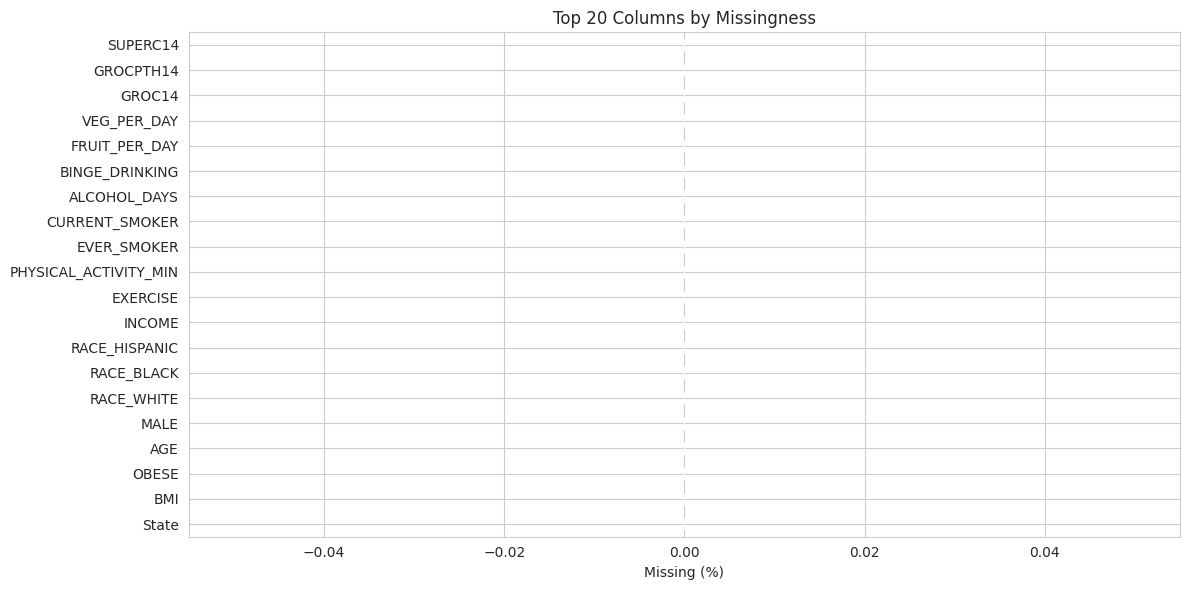

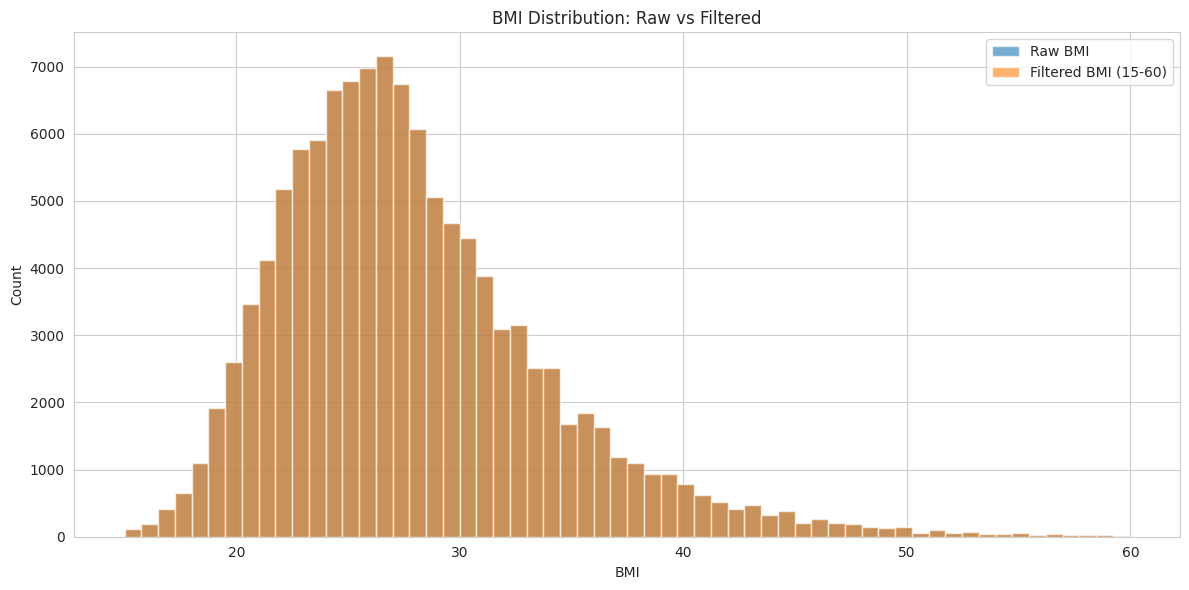

[skip] 'SEX' not found
[skip] 'INCOME2' not found


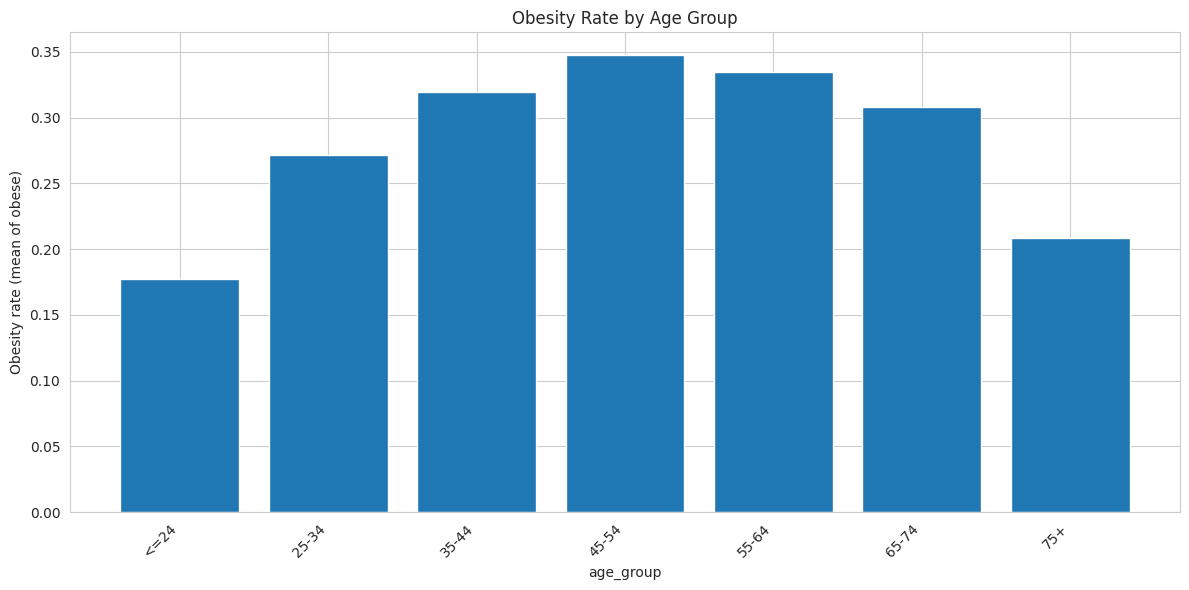


=== Top numeric features by |corr| with obese ===
OBESE                    1.000
BMI                      0.788
EXERCISE                 0.113
RACE_BLACK               0.086
INCOME                   0.077
FSRPTH14                 0.059
RACE_WHITE               0.056
SPECSPTH14               0.050
SNAPSPTH16               0.049
SUPERCPTH14              0.047
ALCOHOL_DAYS             0.044
PHYSICAL_ACTIVITY_MIN    0.039
PC_FSRSALES12            0.035
FRUIT_PER_DAY            0.030
CONVSPTH14               0.029
Name: obese, dtype: float64


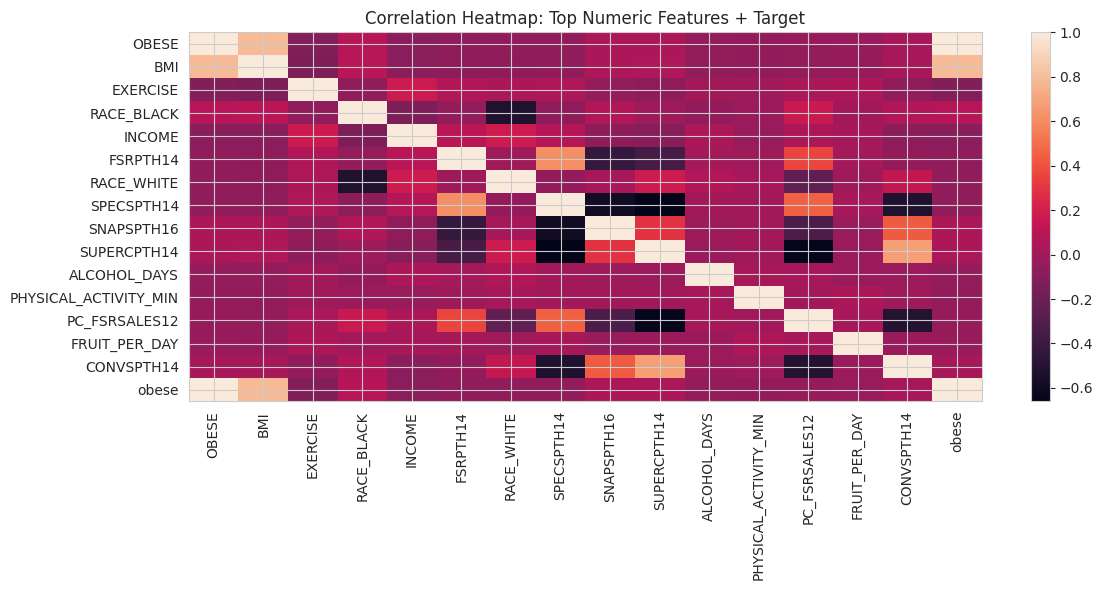

[skip] 'PA1MIN_' not found
[skip] 'EXERANY2' not found
[skip] 'FRUIT2' not found
[skip] 'VEGETAB2' not found
[skip] 'ALCDAY5' not found
[skip] 'SMOKE100' not found
[skip] 'DRNK3GE5' not found


In [33]:
# ---------- 1) Identify / construct BMI ----------
def build_bmi(df: pd.DataFrame) -> pd.Series:
    """
    BRFSS often stores BMI as _BMI5 = BMI * 100.
    If you already have 'BMI' or 'bmi', it will use that.
    Returns a float Series with BMI in normal units.
    """
    if "BMI" in df.columns:
        return pd.to_numeric(df["BMI"], errors="coerce")
    if "bmi" in df.columns:
        return pd.to_numeric(df["bmi"], errors="coerce")
    if "_BMI5" in df.columns:
        s = pd.to_numeric(df["_BMI5"], errors="coerce")
        # BRFSS _BMI5 is typically BMI * 100
        return s / 100.0
    raise ValueError("No BMI column found. Expected one of: 'BMI', 'bmi', '_BMI5'.")

df = df.copy()

df["bmi_raw"] = build_bmi(df)

# ---------- 2) BMI filtering (outliers) + target definition ----------
BMI_MIN, BMI_MAX = 15, 60  # use whatever you stated in your report
df["bmi_clean"] = df["bmi_raw"].where(df["bmi_raw"].between(BMI_MIN, BMI_MAX))

# Obesity target (1 if BMI >= 30, else 0). Uses clean BMI.
df["obese"] = np.where(df["bmi_clean"].isna(), np.nan, (df["bmi_clean"] >= 30).astype(int))

# If you want to drop rows where obese is missing (common before modeling):
df_model = df.dropna(subset=["obese"]).copy()
df_model["obese"] = df_model["obese"].astype(int)

# ---------- 3) Dataset snapshot (table-like outputs) ----------
print("=== Dataset Snapshot ===")
print("Original shape:", df.shape)
print("Modeling shape (after dropping missing target):", df_model.shape)
print("\nTarget balance (counts):")
print(df_model["obese"].value_counts(dropna=False))
print("\nTarget balance (percent):")
print((df_model["obese"].value_counts(normalize=True) * 100).round(2))

# If you have train/val/test already split, print those shapes too:
# print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

# ---------- 4) Missingness summary (top 20) ----------
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
missing_tbl = missing_pct.head(20).to_frame(name="missing_%").round(2)
print("\n=== Top 20 columns by missingness (%) ===")
print(missing_tbl)

# Plot: top 20 missingness
plt.figure()
missing_tbl.sort_values("missing_%", ascending=True)["missing_%"].plot(kind="barh")
plt.xlabel("Missing (%)")
plt.title("Top 20 Columns by Missingness")
plt.tight_layout()
plt.show()

# ---------- 5) BMI distribution (before vs after filtering) ----------
plt.figure()
plt.hist(df["bmi_raw"].dropna(), bins=60, alpha=0.6, label="Raw BMI")
plt.hist(df["bmi_clean"].dropna(), bins=60, alpha=0.6, label=f"Filtered BMI ({BMI_MIN}-{BMI_MAX})")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.title("BMI Distribution: Raw vs Filtered")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 6) Obesity rate by subgroup (only runs if columns exist) ----------
def plot_obesity_rate_by(col_name: str, title: str, sort_index=True, max_categories=30):
    if col_name not in df_model.columns:
        print(f"[skip] '{col_name}' not found")
        return

    g = df_model.groupby(col_name)["obese"].mean().dropna()
    if sort_index:
        g = g.sort_index()
    else:
        g = g.sort_values(ascending=False)

    # limit categories for readability
    if len(g) > max_categories:
        g = g.head(max_categories)

    plt.figure()
    plt.bar(g.index.astype(str), g.values)
    plt.xlabel(col_name)
    plt.ylabel("Obesity rate (mean of obese)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Sex (BRFSS often uses SEX with codes 1/2)
plot_obesity_rate_by("SEX", "Obesity Rate by Sex (coded)")

# Income (BRFSS often uses INCOME2 with ordinal codes)
plot_obesity_rate_by("INCOME2", "Obesity Rate by Income Category (coded)")

# Age groups: create age bins if you have _AGE80 (age in years) or similar
age_col = None
for c in ["_AGE80", "AGE", "age", "Age"]:
    if c in df_model.columns:
        age_col = c
        break

if age_col is not None:
    df_model["age_years"] = pd.to_numeric(df_model[age_col], errors="coerce")

    # example bins (adjust as needed)
    bins = [0, 24, 34, 44, 54, 64, 74, 120]
    labels = ["<=24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]
    df_model["age_group"] = pd.cut(df_model["age_years"], bins=bins, labels=labels, right=True)

    plot_obesity_rate_by("age_group", "Obesity Rate by Age Group", sort_index=True)
else:
    print("[skip] No age column found (looked for _AGE80/AGE/age/Age)")

# ---------- 7) Correlation: find top numeric predictors vs target + heatmap ----------
# Keep numeric columns only (excluding obvious IDs if you want)
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

# Remove the raw BMI columns if you don't want them competing with predictors
# (optional, depending on whether you used BMI-derived target only)
for drop_c in ["bmi_raw", "bmi_clean"]:
    if drop_c in numeric_cols:
        numeric_cols.remove(drop_c)

# Always keep target
if "obese" not in numeric_cols:
    numeric_cols.append("obese")

corr = df_model[numeric_cols].corr(numeric_only=True)

# Pick top-k features most correlated with target
k = 15
target_corr = corr["obese"].drop("obese").abs().sort_values(ascending=False)
top_feats = target_corr.head(k).index.tolist()

print("\n=== Top numeric features by |corr| with obese ===")
print(target_corr.head(k).round(3))

# Heatmap for top features + target
heat_cols = top_feats + ["obese"]
heat = corr.loc[heat_cols, heat_cols]

plt.figure()
plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(heat_cols)), heat_cols, rotation=90)
plt.yticks(range(len(heat_cols)), heat_cols)
plt.title("Correlation Heatmap: Top Numeric Features + Target")
plt.colorbar()
plt.tight_layout()
plt.show()

# ---------- 8) Optional: boxplots for a few key predictors by class ----------
def boxplot_by_class(feature: str):
    if feature not in df_model.columns:
        print(f"[skip] '{feature}' not found")
        return
    x0 = pd.to_numeric(df_model.loc[df_model["obese"] == 0, feature], errors="coerce").dropna()
    x1 = pd.to_numeric(df_model.loc[df_model["obese"] == 1, feature], errors="coerce").dropna()

    plt.figure()
    plt.boxplot([x0, x1], labels=["Not obese (0)", "Obese (1)"])
    plt.ylabel(feature)
    plt.title(f"{feature} by Obesity Class")
    plt.tight_layout()
    plt.show()

# Try common BRFSS predictors (runs only if present)
for feat in ["PA1MIN_", "EXERANY2", "FRUIT2", "VEGETAB2", "ALCDAY5", "SMOKE100", "DRNK3GE5"]:
    boxplot_by_class(feat)

## 1. Setup and Data Loading

In [34]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, silhouette_score
)

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [35]:
# Load the cleaned dataset
# UPDATE THIS PATH for your environment (Google Colab, local, etc.)
df = pd.read_csv('cleaned_obesity_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nObesity rate: {df['OBESE'].mean():.2%}")
print(f"Sample size: {len(df):,} individuals")
print(f"Number of states: {df['State'].nunique()}")

Dataset shape: (115853, 39)

Columns: ['State', 'BMI', 'OBESE', 'AGE', 'MALE', 'RACE_WHITE', 'RACE_BLACK', 'RACE_HISPANIC', 'INCOME', 'EXERCISE', 'PHYSICAL_ACTIVITY_MIN', 'EVER_SMOKER', 'CURRENT_SMOKER', 'ALCOHOL_DAYS', 'BINGE_DRINKING', 'FRUIT_PER_DAY', 'VEG_PER_DAY', 'GROC14', 'GROCPTH14', 'SUPERC14', 'SUPERCPTH14', 'CONVS14', 'CONVSPTH14', 'SPECS14', 'SPECSPTH14', 'SNAPS16', 'SNAPSPTH16', 'FFR14', 'FFRPTH14', 'FSR14', 'FSRPTH14', 'PC_FFRSALES12', 'PC_FSRSALES12', 'PCT_LACCESS_POP15', 'PCT_LACCESS_LOWI15', 'PCT_LACCESS_CHILD15', 'PCT_LACCESS_SENIORS15', 'PCT_LACCESS_SNAP15', 'State_Name']

Obesity rate: 29.45%
Sample size: 115,853 individuals
Number of states: 15


## 2. Data Preparation for Modeling

In [36]:
# Separate features and target
# Exclude: State, State_Name (categorical identifiers), BMI (directly determines obesity), OBESE (target)
exclude_cols = ['State', 'State_Name', 'BMI', 'OBESE']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df['OBESE'].copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nFeatures used ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

# Double-check all columns are numeric
non_numeric = X.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print(f"\n⚠️ WARNING: Non-numeric columns found: {non_numeric}")
    print("Removing them...")
    X = X.drop(non_numeric, axis=1)
    feature_cols = [col for col in feature_cols if col not in non_numeric]
    print(f"New feature count: {len(feature_cols)}")
else:
    print("\n✓ All columns are numeric")

Feature matrix X shape: (115853, 35)
Target vector y shape: (115853,)

Features used (35):
 1. AGE
 2. MALE
 3. RACE_WHITE
 4. RACE_BLACK
 5. RACE_HISPANIC
 6. INCOME
 7. EXERCISE
 8. PHYSICAL_ACTIVITY_MIN
 9. EVER_SMOKER
10. CURRENT_SMOKER
11. ALCOHOL_DAYS
12. BINGE_DRINKING
13. FRUIT_PER_DAY
14. VEG_PER_DAY
15. GROC14
16. GROCPTH14
17. SUPERC14
18. SUPERCPTH14
19. CONVS14
20. CONVSPTH14
21. SPECS14
22. SPECSPTH14
23. SNAPS16
24. SNAPSPTH16
25. FFR14
26. FFRPTH14
27. FSR14
28. FSRPTH14
29. PC_FFRSALES12
30. PC_FSRSALES12
31. PCT_LACCESS_POP15
32. PCT_LACCESS_LOWI15
33. PCT_LACCESS_CHILD15
34. PCT_LACCESS_SENIORS15
35. PCT_LACCESS_SNAP15

✓ All columns are numeric


In [37]:
# Check for any remaining missing values
missing = X.isnull().sum()
if missing.sum() > 0:
    print("WARNING: Missing values detected:")
    print(missing[missing > 0])
else:
    print("✓ No missing values in feature matrix")

# Verify no infinite values - check each float column individually
inf_cols = []
for col in X.columns:
    if X[col].dtype in ['float64', 'float32']:
        if np.isinf(X[col]).any():
            inf_cols.append(col)

if inf_cols:
    print(f"WARNING: Infinite values detected in columns: {inf_cols}")
else:
    print("✓ No infinite values in feature matrix")

✓ No missing values in feature matrix
✓ No infinite values in feature matrix


In [38]:
# Train-test split (80-20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X):.1%})")
print(f"Test set size: {len(X_test):,} ({len(X_test)/len(X):.1%})")
print(f"\nObesity rate in training set: {y_train.mean():.2%}")
print(f"Obesity rate in test set: {y_test.mean():.2%}")

Training set size: 92,682 (80.0%)
Test set size: 23,171 (20.0%)

Obesity rate in training set: 29.45%
Obesity rate in test set: 29.45%


In [39]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Features standardized successfully!")
print(f"\nExample - AGE before scaling:")
print(f"  Mean: {X_train['AGE'].mean():.2f}, Std: {X_train['AGE'].std():.2f}")
print(f"\nAGE after scaling:")
print(f"  Mean: {X_train_scaled['AGE'].mean():.2f}, Std: {X_train_scaled['AGE'].std():.2f}")

Features standardized successfully!

Example - AGE before scaling:
  Mean: 55.32, Std: 17.41

AGE after scaling:
  Mean: 0.00, Std: 1.00


## 3. k-Nearest Neighbors (kNN) - Baseline Model

In [40]:
# For faster execution, we'll use a smaller parameter grid
# (The full grid search can take 30+ minutes)
param_grid_knn = {
    'n_neighbors': [5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running Grid Search for kNN...")
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_knn.best_params_}")
print(f"Best CV accuracy: {grid_search_knn.best_score_:.4f}")

# Test set evaluation
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
y_pred_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_pred_proba_knn)

print(f"\nTest Accuracy: {knn_accuracy:.4f}")
print(f"ROC AUC: {knn_auc:.4f}")

Running Grid Search for kNN...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Best CV accuracy: 0.6938

Test Accuracy: 0.6940
ROC AUC: 0.6144


## 4. Decision Tree

In [41]:
param_grid_tree = {
    'max_depth': [5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

tree = DecisionTreeClassifier(random_state=42)

print("Running Grid Search for Decision Tree...")
grid_search_tree = GridSearchCV(tree, param_grid_tree, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_tree.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_tree.best_params_}")
print(f"Best CV accuracy: {grid_search_tree.best_score_:.4f}")

# Test set evaluation
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test_scaled)
y_pred_proba_tree = best_tree.predict_proba(X_test_scaled)[:, 1]

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_pred_proba_tree)

print(f"\nTest Accuracy: {tree_accuracy:.4f}")
print(f"ROC AUC: {tree_auc:.4f}")

Running Grid Search for Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV accuracy: 0.7051

Test Accuracy: 0.7048
ROC AUC: 0.6321


## 5. Logistic Regression

In [42]:
# Parameter grid for Logistic Regression
param_grid_log = {
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced'],
    'max_iter': [300, 500]
}

log_reg = LogisticRegression()

print("Running Grid Search for Logistic Regression...")
grid_search_log = GridSearchCV(
    log_reg,
    param_grid_log,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_log.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_log.best_params_}")
print(f"Best CV accuracy: {grid_search_log.best_score_:.4f}")

# Test set evaluation
best_log = grid_search_log.best_estimator_
y_pred_log = best_log.predict(X_test_scaled)
y_pred_proba_log = best_log.predict_proba(X_test_scaled)[:, 1]

log_accuracy = accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_pred_proba_log)

print(f"\nTest Accuracy: {log_accuracy:.4f}")
print(f"ROC AUC: {log_auc:.4f}")


Running Grid Search for Logistic Regression...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters: {'C': 0.01, 'class_weight': None, 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.7045

Test Accuracy: 0.7063
ROC AUC: 0.6188


## 6. Model Comparison

In [43]:
# Compare all three models
comparison_df = pd.DataFrame({
    'Model': ['k-Nearest Neighbors', 'Decision Tree', 'Logistic Regression'],
    'Test Accuracy': [knn_accuracy, tree_accuracy, log_accuracy],
    'ROC AUC': [knn_auc, tree_auc, log_auc],
    'CV Accuracy': [
        grid_search_knn.best_score_,
        grid_search_tree.best_score_,
        grid_search_log.best_score_
    ]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nBest Model (by Test Accuracy): {comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']}")
print(f"Best Model (by ROC AUC): {comparison_df.loc[comparison_df['ROC AUC'].idxmax(), 'Model']}")

MODEL COMPARISON
              Model  Test Accuracy  ROC AUC  CV Accuracy
k-Nearest Neighbors       0.693971 0.614370     0.693802
      Decision Tree       0.704803 0.632116     0.705088
Logistic Regression       0.706314 0.618829     0.704517

Best Model (by Test Accuracy): Logistic Regression
Best Model (by ROC AUC): Decision Tree


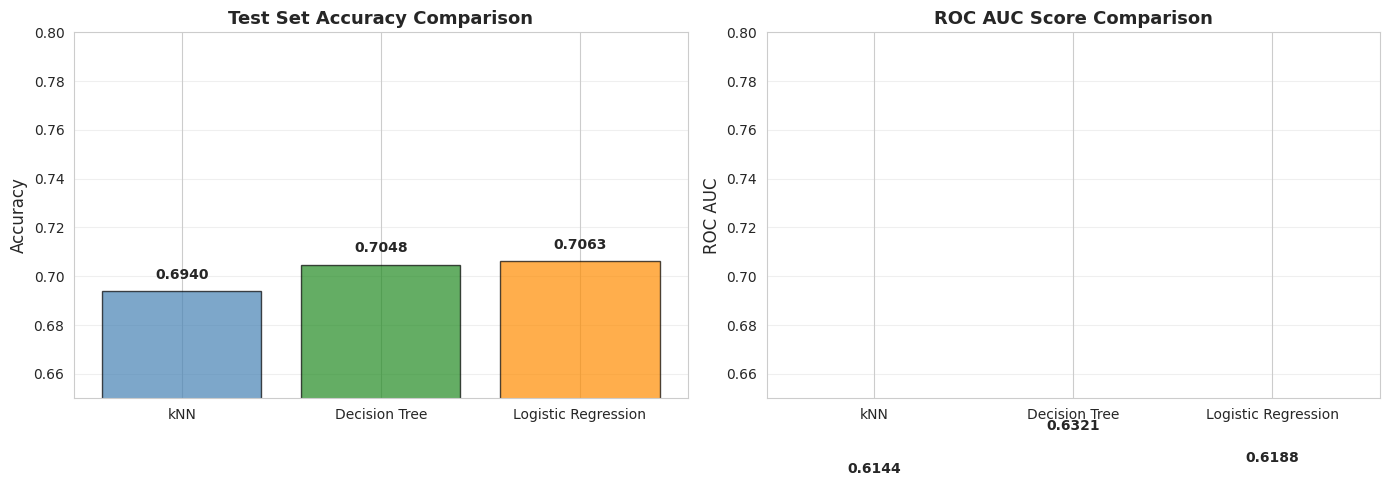

Plot saved: all_models_comparison.png


In [44]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['kNN', 'Decision Tree', 'Logistic Regression']
accuracies = [knn_accuracy, tree_accuracy, log_accuracy]
aucs = [knn_auc, tree_auc, log_auc]
colors = ['steelblue', 'forestgreen', 'darkorange']

# Plot 1: Accuracy
axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Test Set Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([0.65, 0.80])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: AUC
axes[1].bar(models, aucs, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('ROC AUC', fontsize=12)
axes[1].set_title('ROC AUC Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim([0.65, 0.80])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved: all_models_comparison.png")

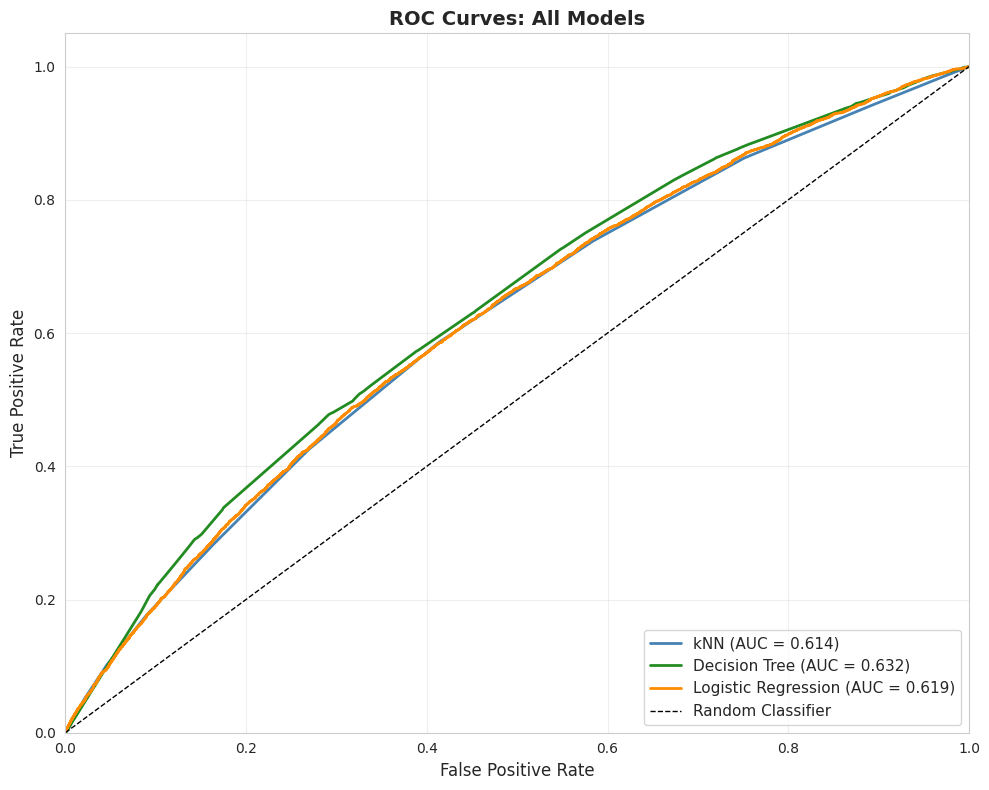

Plot saved: roc_curves_all_models.png


In [45]:
# ROC Curves for all models
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_proba_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_log)

plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, linewidth=2, label=f'kNN (AUC = {knn_auc:.3f})', color='steelblue')
plt.plot(fpr_tree, tpr_tree, linewidth=2, label=f'Decision Tree (AUC = {tree_auc:.3f})', color='forestgreen')
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Logistic Regression (AUC = {log_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved: roc_curves_all_models.png")

## 7. Feature Importance Analysis (Decision Tree vs Logistic Regression)

In [46]:
# Get feature importances from tree and logistic regression (use coefficients)
log_reg_coef = best_log.coef_[0]  # 1D array

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Decision_Tree': best_tree.feature_importances_,
    'Logistic_Regression': log_reg_coef
})

# Sort by absolute coefficient magnitude for better interpretation
feature_importance_df['LogReg_Abs'] = feature_importance_df['Logistic_Regression'].abs()

# Sort by logistic regression importance
feature_importance_df = feature_importance_df.sort_values('LogReg_Abs', ascending=False)

print("\nTop 15 Most Important Features (Logistic Regression):")
print(feature_importance_df[['Feature', 'Logistic_Regression', 'Decision_Tree']].head(15).to_string(index=False))


Top 15 Most Important Features (Logistic Regression):
              Feature  Logistic_Regression  Decision_Tree
             EXERCISE            -0.218457       0.209174
           RACE_BLACK             0.167033       0.071526
       CURRENT_SMOKER            -0.135386       0.059135
             FSRPTH14            -0.114633       0.000000
    PCT_LACCESS_POP15            -0.112348       0.002125
PHYSICAL_ACTIVITY_MIN            -0.106995       0.059296
               INCOME            -0.103317       0.040205
        FRUIT_PER_DAY            -0.087680       0.010305
            GROCPTH14             0.084705       0.018934
         ALCOHOL_DAYS            -0.082761       0.034939
        RACE_HISPANIC             0.078845       0.003708
             SUPERC14             0.075546       0.000000
  PCT_LACCESS_CHILD15            -0.067331       0.002215
          EVER_SMOKER             0.067306       0.001433
                FFR14            -0.066906       0.002330


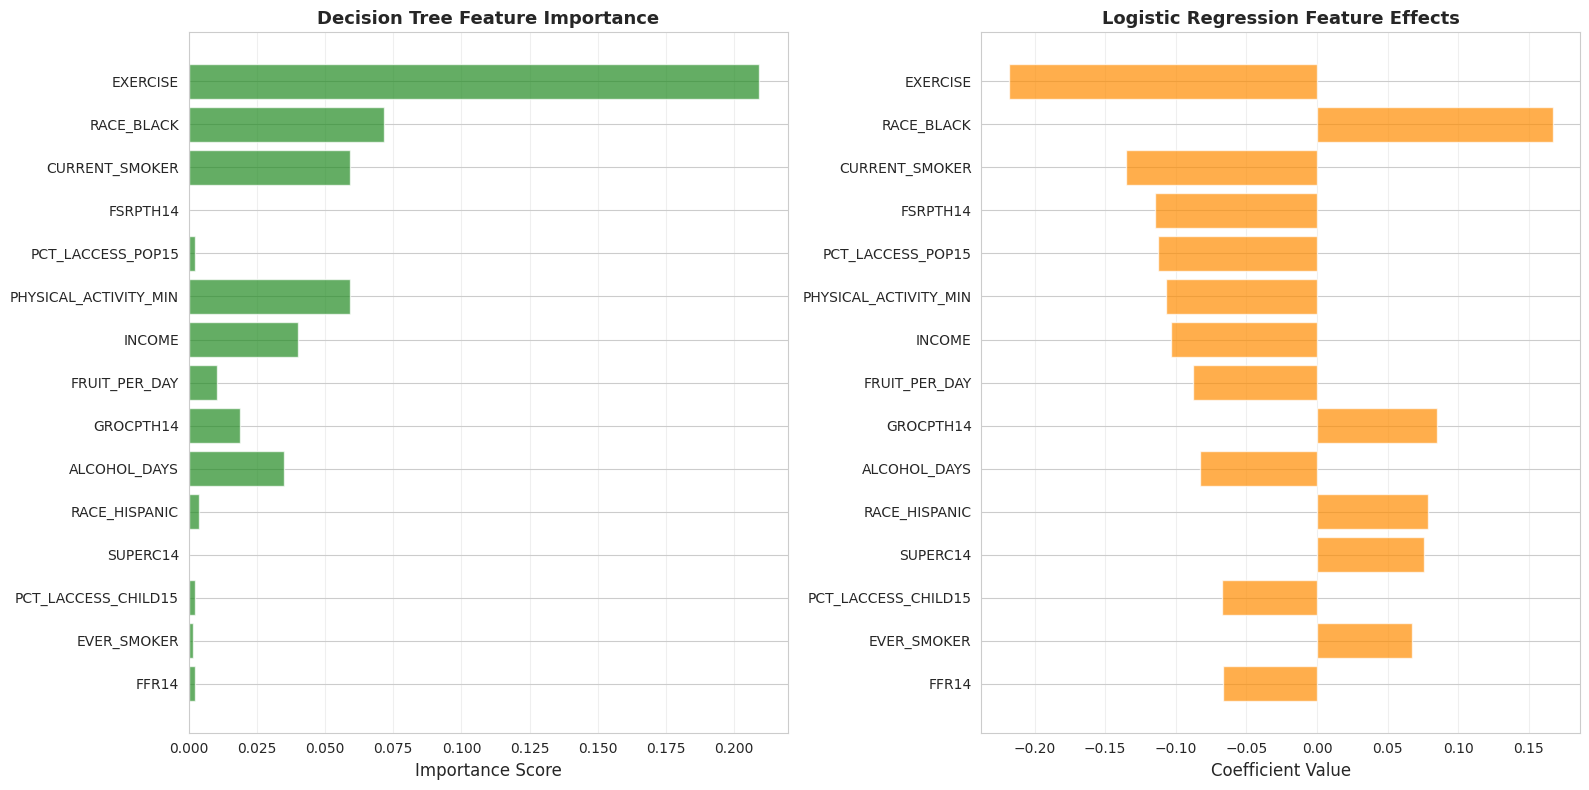

Plot saved: feature_importance_comparison.png


In [47]:
# Visualize feature importance comparison
top_15 = feature_importance_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Decision Tree importance
axes[0].barh(range(len(top_15)), top_15['Decision_Tree'], color='forestgreen', alpha=0.7)
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['Feature'])
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Decision Tree Feature Importance', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Logistic Regression coefficients
axes[1].barh(range(len(top_15)), top_15['Logistic_Regression'], color='darkorange', alpha=0.7)
axes[1].set_yticks(range(len(top_15)))
axes[1].set_yticklabels(top_15['Feature'])
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title('Logistic Regression Feature Effects', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved: feature_importance_comparison.png")


## 8. Confusion Matrices for All Models

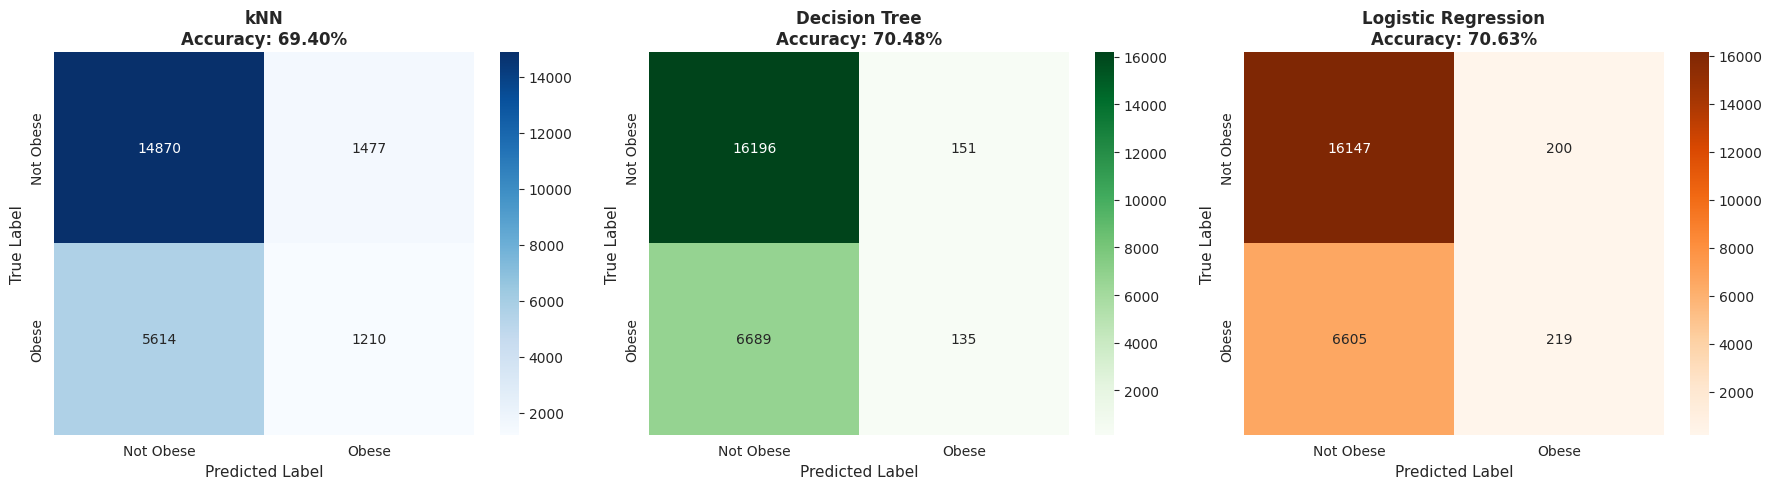

Plot saved: confusion_matrices_all.png


In [48]:
# Create confusion matrices for all models
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_rf = confusion_matrix(y_test, y_pred_log)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# kNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Obese', 'Obese'],
            yticklabels=['Not Obese', 'Obese'])
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title(f'kNN\nAccuracy: {knn_accuracy:.2%}', fontsize=12, fontweight='bold')

# Decision Tree
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Obese', 'Obese'],
            yticklabels=['Not Obese', 'Obese'])
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_title(f'Decision Tree\nAccuracy: {tree_accuracy:.2%}', fontsize=12, fontweight='bold')

# Logistic Regression
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Not Obese', 'Obese'],
            yticklabels=['Not Obese', 'Obese'])
axes[2].set_ylabel('True Label', fontsize=11)
axes[2].set_xlabel('Predicted Label', fontsize=11)
axes[2].set_title(f'Logistic Regression\nAccuracy: {log_accuracy:.2%}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved: confusion_matrices_all.png")

## 9. Classification Reports

In [49]:
print("="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

print("\nk-NEAREST NEIGHBORS:")
print("-" * 80)
print(classification_report(y_test, y_pred_knn, target_names=['Not Obese', 'Obese']))

print("\nDECISION TREE:")
print("-" * 80)
print(classification_report(y_test, y_pred_tree, target_names=['Not Obese', 'Obese']))

print("\nLOSISTIC REGRESSION:")
print("-" * 80)
print(classification_report(y_test, y_pred_log, target_names=['Not Obese', 'Obese']))

DETAILED CLASSIFICATION REPORTS

k-NEAREST NEIGHBORS:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   Not Obese       0.73      0.91      0.81     16347
       Obese       0.45      0.18      0.25      6824

    accuracy                           0.69     23171
   macro avg       0.59      0.54      0.53     23171
weighted avg       0.64      0.69      0.64     23171


DECISION TREE:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   Not Obese       0.71      0.99      0.83     16347
       Obese       0.47      0.02      0.04      6824

    accuracy                           0.70     23171
   macro avg       0.59      0.51      0.43     23171
weighted avg       0.64      0.70      0.59     23171


LOSISTIC REGRESSION:
--------------------------------------------------------------------------------
           

## 10. Export Results

In [50]:
# Create comprehensive results summary
results_summary = pd.DataFrame({
    'Model': ['k-Nearest Neighbors', 'Decision Tree', 'Logistic Regression'],
    'Test_Accuracy': [f"{knn_accuracy:.4f}", f"{tree_accuracy:.4f}", f"{log_accuracy:.4f}"],
    'ROC_AUC': [f"{knn_auc:.4f}", f"{tree_auc:.4f}", f"{log_auc:.4f}"],
    'CV_Accuracy': [
        f"{grid_search_knn.best_score_:.4f}",
        f"{grid_search_tree.best_score_:.4f}",
        f"{grid_search_log.best_score_:.4f}"
    ],
    'Best_Parameters': [
        str(grid_search_knn.best_params_),
        str(grid_search_tree.best_params_),
        str(grid_search_log.best_params_)
    ]
})

# Save results
results_summary.to_csv('model_results_with_log_reg.csv', index=False)
feature_importance_df.to_csv('feature_importance_all.csv', index=False)

print("Results exported to CSV files:")
print("  - model_results_with_log_reg.csv")
print("  - feature_importance_all.csv")

print("\nFinal Results Summary:")
print(results_summary.to_string(index=False))


Results exported to CSV files:
  - model_results_with_log_reg.csv
  - feature_importance_all.csv

Final Results Summary:
              Model Test_Accuracy ROC_AUC CV_Accuracy                                                                         Best_Parameters
k-Nearest Neighbors        0.6940  0.6144      0.6938                        {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
      Decision Tree        0.7048  0.6321      0.7051 {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Logistic Regression        0.7063  0.6188      0.7045  {'C': 0.01, 'class_weight': None, 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}
